<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509Files/blob/main/OPIM5509_Module5_Files/notebooks/Dave_s_GLoVE_Example.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS — M5 · 8 — Learned vs pretrained: GloVe, frozen (part 1 of 2 - tiny docs; finish in M5_2a_Word_Embeddings)
- 10 tiny reviews, 5 good and 5 bad, so you can see every number.
- one_hot(d, 50) is a HASH, not a dictionary: 'excellent', 'weak' and 'poor' ALL land on 35. Pad to 4 words.
- Embedding(50, 8) = 400 parameters (50 words x 8 numbers). Flatten 4 x 8 = 32 -> Dense(1) = 33. Total 433.
- Training accuracy 90% - capped by that collision: 'Excellent!' and 'Weak' are the SAME input with opposite labels. Great 'why' moment.
- get_weights(): the embedding is just a 50 x 8 lookup table. embeddings[34] = one word's 8 numbers.
- Part 2, borrow GloVe: a real Tokenizer (no collisions) -> 14 words + padding = 15 rows. GloVe = 400,000 words x 100 numbers learned from 6 billion words.
- embedding_matrix 15 x 100 loaded with trainable=False: 1,500 frozen parameters, only the 401 in Dense learn. Accuracy 100%. Loss curves are training-only here: 10 documents, no validation set.
-->

# Word Embeddings: learn your own, or borrow GloVe

--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

Two ways to turn words into vectors. First we **learn** an embedding from a handful of tiny documents, so you can see every number. Then we **borrow** one: GloVe vectors that someone else trained on six billion words, loaded into a frozen Embedding layer.

In [1]:
# seed everything: same numbers on my screen and yours
# (and we re-seed right before every model build, so model 2 is as reproducible as model 1)
import keras
import tensorflow as tf

keras.utils.set_random_seed(5509)
tf.config.experimental.enable_op_determinism()

THESE ARE THE ENCODED DOCS
[[24, 4], [44, 23], [30, 32], [39, 23], [35], [35], [35, 32], [39, 44], [35, 23], [29, 28, 4, 40]]
THESE ARE THE PADDED, ONE HOT DOCS
[[24  4  0  0]
 [44 23  0  0]
 [30 32  0  0]
 [39 23  0  0]
 [35  0  0  0]
 [35  0  0  0]
 [35 32  0  0]
 [39 44  0  0]
 [35 23  0  0]
 [29 28  4 40]]


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 4, 8)           │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 433 (1.69 KB)

 Trainable params: 433 (1.69 KB)

 Non-trainable params: 0 (0.00 B)

None


Accuracy: 89.999998


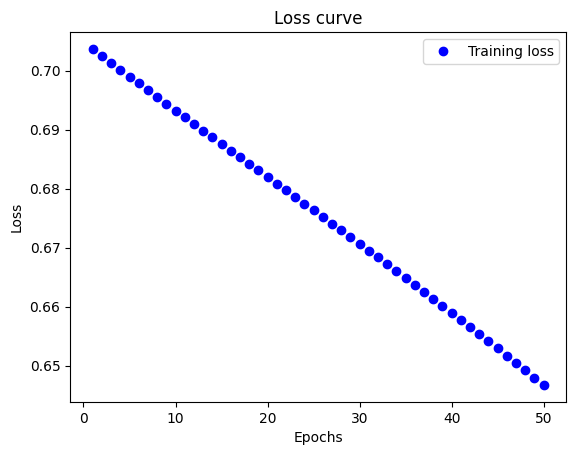

epochs run: 50 | final training loss: 0.6467


In [2]:
# link: https://machinelearningmastery.com/use-word-embedding-layers-deep-learning-keras/

# Example 3: Learning an embedding
from numpy import array
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Embedding

# define documents
# EXERCISE: write more here... you can even use a .csv file instad of typing manually...
docs = ['Well done!',
		'Good work',
		'Great effort',
		'nice work',
		'Excellent!',
		'Weak',
		'Poor effort!',
		'not good',
		'poor work',
		'Could have done better.']
# define class labels
labels = array([1,1,1,1,1,0,0,0,0,0])
# integer encode the documents
vocab_size = 50 # play with this...
encoded_docs = []
for d in docs:
    encoded_docs.append(one_hot(d, vocab_size))
print("===========================================================")
print("THESE ARE THE ENCODED DOCS")
print("===========================================================")
print(encoded_docs)
# pad documents to a max length of 4 words
# EXERCISE: play with the length of words, more or less... how does it chop them off?
max_length = 4
padded_docs = pad_sequences(encoded_docs, maxlen=max_length, padding='post')
print("===========================================================")
print("THESE ARE THE PADDED, ONE HOT DOCS")
print("===========================================================")
print(padded_docs)

# define the model
keras.utils.set_random_seed(5509)   # re-seed right before the build: same starting weights every run
model = Sequential()
model.add(Input(shape=(max_length,)))
model.add(Embedding(vocab_size, 8))
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# summarize the model
print(model.summary())

# fit the model
history = model.fit(padded_docs, labels, epochs=50, verbose=0)

# evaluate the model
loss, accuracy = model.evaluate(padded_docs, labels, verbose=0)
print('Accuracy: %f' % (accuracy*100))

# loss curve - only 10 documents, so there is no validation set here: training loss only
import matplotlib.pyplot as plt

loss = history.history['loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.title('Loss curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print('epochs run:', len(loss), '| final training loss:', round(loss[-1], 4))

In [3]:
# this also looks like a great example - visualizing the embeddings is key!
# link: https://towardsdatascience.com/neural-network-embeddings-explained-4d028e6f0526

In [4]:
# get access to the weights! since we made them 8-dimensional, each word is 8 dimensional!

# link: https://stackoverflow.com/questions/51235118/how-to-get-word-vectors-from-keras-embedding-layer

# access the embedding layer through the constructed model
# first `0` refers to the position of embedding layer in the `model`
embeddings = model.layers[0].get_weights()[0]

# this is the shape of the embeddings
print(embeddings.shape)

# these are the embeddings
print(embeddings)

(50, 8)
[[-0.03430845 -0.04777596  0.0508467  -0.00064071 -0.04692214 -0.02274309
   0.03369888 -0.00231593]
 [-0.02143312  0.02878848 -0.04362532  0.01427004 -0.02524848 -0.03733796
   0.03409103  0.00832778]
 [ 0.04027962 -0.01295257 -0.0226294  -0.03127741  0.03488712 -0.04876656
  -0.04253932  0.0315665 ]
 [-0.0305705  -0.01584715 -0.03483133  0.0474941   0.03870985 -0.0450816
  -0.04021901 -0.04172449]
 [ 0.07047153  0.08959986 -0.00340314 -0.04367623  0.03783377 -0.10879018
   0.08153073 -0.0747408 ]
 [ 0.03588464 -0.03651452  0.01977242  0.04726576  0.00084599 -0.01932387
  -0.03822206  0.01255682]
 [-0.00492672  0.03341397  0.01837354  0.01706633  0.02630946  0.03236563
   0.02598004 -0.04275658]
 [ 0.00752636 -0.0018538  -0.03827386 -0.04912629 -0.00710167 -0.03895186
   0.0445367  -0.00819396]
 [ 0.03641751  0.0136386  -0.04449719 -0.00173543  0.00045422  0.04622306
  -0.0235123  -0.01884337]
 [ 0.03651175 -0.02517268 -0.01937779 -0.00294854 -0.02823142 -0.0356374
   0.044640

In [5]:
# do a lookup for each word
embeddings[34]

array([ 0.04893496, -0.00542587, -0.01898921,  0.00373112,  0.03141545,
       -0.02186241,  0.03957412, -0.03286856], dtype=float32)

In [6]:
# # Link to the glove.6B.100d.txt file on Github
# "https://github.com/drdave-teaching/OPIM5509Files/raw/refs/heads/main/OPIM5509_Module5_Files/data/glove.6B.100d.txt"

In [7]:
# https://drive.google.com/file/d/1OZ9fiJCZV1mIpGvw_mS4ZJKZS-QaoJ5S/view?usp=sharing
!gdown 1OZ9fiJCZV1mIpGvw_mS4ZJKZS-QaoJ5S

Loaded 400000 word vectors.
[[6, 2], [3, 1], [7, 4], [8, 1], [9], [10], [5, 4], [11, 3], [5, 1], [12, 13, 2, 14]]
[[ 6  2  0  0]
 [ 3  1  0  0]
 [ 7  4  0  0]
 [ 8  1  0  0]
 [ 9  0  0  0]
 [10  0  0  0]
 [ 5  4  0  0]
 [11  3  0  0]
 [ 5  1  0  0]
 [12 13  2 14]]


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 4, 100)         │         1,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           401 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,901 (7.43 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 1,500 (5.86 KB)

None


Accuracy: 100.000000


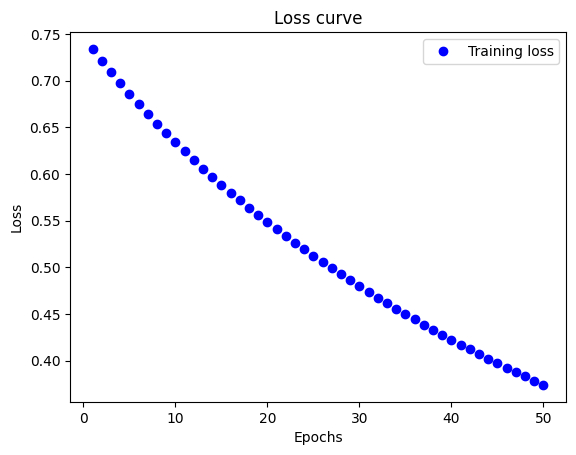

epochs run: 50 | final training loss: 0.3739


In [8]:
# now let's try using GLoVE (make sure this is on your computer!) - this can go into a different script?
# link: https://machinelearningmastery.com/use-word-embedding-layers-deep-learning-keras/

# load the whole embedding into memory
from numpy import array
from numpy import asarray
from numpy import zeros
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Embedding

embeddings_index = dict()

f = open("/content/glove.6B.100d.txt")
for line in f:
	values = line.split()
	word = values[0]
	coefs = asarray(values[1:], dtype='float32')
	embeddings_index[word] = coefs
f.close()
print('Loaded %s word vectors.' % len(embeddings_index))


# define documents
docs = ['Well done!',
		'Good work',
		'Great effort',
		'nice work',
		'Excellent!',
		'Weak',
		'Poor effort!',
		'not good',
		'poor work',
		'Could have done better.']
# define class labels
labels = array([1,1,1,1,1,0,0,0,0,0])
# prepare tokenizer - we can break each out into a different cell in class
t = Tokenizer()
t.fit_on_texts(docs)
vocab_size = len(t.word_index) + 1
# integer encode the documents
encoded_docs = t.texts_to_sequences(docs)
print(encoded_docs)
# pad documents to a max length of 4 words
max_length = 4
padded_docs = pad_sequences(encoded_docs, maxlen=max_length, padding='post')
print(padded_docs)

# create a weight matrix for words in training docs
embedding_matrix = zeros((vocab_size, 100))
for word, i in t.word_index.items():
	embedding_vector = embeddings_index.get(word)
	if embedding_vector is not None:
		embedding_matrix[i] = embedding_vector
# define model
keras.utils.set_random_seed(5509)   # re-seed right before the build: same starting weights every run
model = Sequential()
e = Embedding(vocab_size, 100, weights=[embedding_matrix], trainable=False)
model.add(Input(shape=(4,)))
model.add(e)
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# summarize the model
print(model.summary())
# fit the model
history = model.fit(padded_docs, labels, epochs=50, verbose=0)
# evaluate the model
loss, accuracy = model.evaluate(padded_docs, labels, verbose=0)
print('Accuracy: %f' % (accuracy*100))

# loss curve - only 10 documents, so there is no validation set here: training loss only
import matplotlib.pyplot as plt

loss = history.history['loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.title('Loss curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print('epochs run:', len(loss), '| final training loss:', round(loss[-1], 4))

In [9]:
# look at the embedding matrix
print(embedding_matrix.shape) # 15 words, each are 100 dimensions

# these are all of the words and their index... you can look back at the table!
print(t.word_index.items())

# in comparison, this is the ordered dictionary - word and frequency associated with it!
print(t.word_counts)

(15, 100)
dict_items([('work', 1), ('done', 2), ('good', 3), ('effort', 4), ('poor', 5), ('well', 6), ('great', 7), ('nice', 8), ('excellent', 9), ('weak', 10), ('not', 11), ('could', 12), ('have', 13), ('better', 14)])
OrderedDict([('well', 1), ('done', 2), ('good', 2), ('work', 3), ('great', 1), ('effort', 2), ('nice', 1), ('excellent', 1), ('weak', 1), ('poor', 2), ('not', 1), ('could', 1), ('have', 1), ('better', 1)])


In [10]:
# this is the embedding associated with each one!
# note how it goes from 1 to 14, does not include 0 or 15
# you can verify this by looking at t.word_index.items()

# this is the word embedding for "work"
embedding_matrix[1]

array([-1.16190001e-01,  4.54470009e-01, -6.92160010e-01,  3.45799997e-02,
        2.63480008e-01, -3.81390005e-01, -2.27899998e-01,  3.72330010e-01,
       -2.05789998e-01,  2.90199995e-01,  1.21140003e-01, -4.27289993e-01,
        5.55729985e-01, -9.42860022e-02, -4.99669999e-01, -2.94779986e-01,
        7.41090000e-01,  2.51910001e-01, -2.74679989e-01,  2.31910005e-01,
        3.82039999e-03,  4.52519991e-02,  2.49699995e-01, -4.15789992e-01,
        3.13069999e-01, -5.84959984e-01, -3.27389985e-01, -6.61889970e-01,
        1.49090007e-01, -2.57710010e-01, -9.48580027e-01,  4.18089986e-01,
       -2.95379996e-01, -4.27110009e-02, -6.99699998e-01,  5.78920007e-01,
       -6.92709982e-02, -3.96329984e-02, -5.64630004e-03, -2.96160012e-01,
       -5.74479997e-01,  1.60099998e-01, -1.06710002e-01,  1.00960001e-01,
       -4.29560006e-01, -2.77850002e-01, -3.00170004e-01, -6.95370018e-01,
        1.79649994e-01, -4.67229992e-01,  1.25110000e-01, -2.90220007e-02,
       -1.59740001e-01,  

In [11]:
# we can also use a simpleRNN
# and we can also apply these to the IMDB dataset (tomorrow!)